 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           :                 <br>
Student Number : L XXXXX         <br>
Due Date       :                 <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [ ]:
# pip installs

## Imports

In [ ]:
# imports

# Support Functions

Matplotlib is building the font cache; this may take a moment.


True


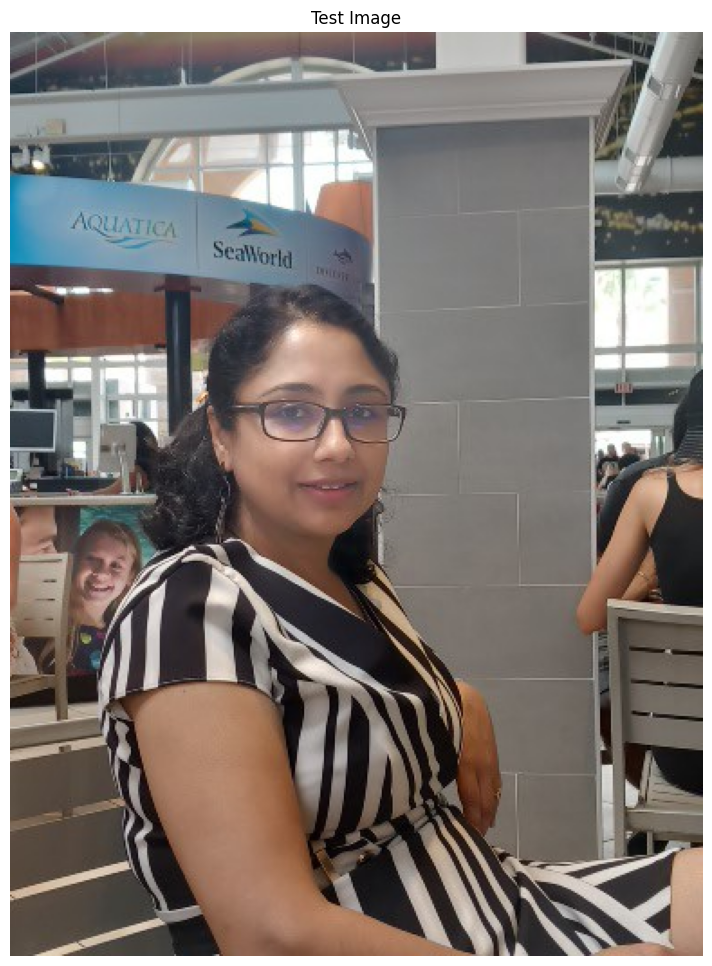

In [10]:
import cv2
import matplotlib.pyplot as plt

def show_image(img, title="Image", figsize=(10, 12)):

    plt.figure(figsize=figsize)

    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()


# Load image
img = cv2.imread("data/test.jpg")

# Check if image loaded correctly
print(img is not None)

# Display image
show_image(img, title="Test Image")

In [15]:
def extract_text_basic(image_path):
    """
    Run OCR on an image and return extracted text.
    """

    img = Image.open(image_path)

    text = pytesseract.image_to_string(img)

    return text

In [16]:
sample_doc = documents[0]

print("Testing OCR on:", sample_doc.name)

text = extract_text_basic(sample_doc)

print("\nExtracted Text:\n")
print(text[:1000])

Testing OCR on: doc1_photo.jpg

Extracted Text:




In [17]:
sample_doc = Path("data/doc1_textbook.png")

print("Testing OCR on:", sample_doc.name)

text = extract_text_basic(sample_doc)

print("\nExtracted Text:\n")
print(text[:1500])


Testing OCR on: doc1_textbook.png

Extracted Text:

The CORE recommender system

The first version of the CORE Recommender was developed in 2011. In 2016, we redeveloped the system and made
many improvements. The new recommender was released in production in autumn 2016 and apart from the fact
that it powers related article recommendations in CORE, itis also deployed at several repositories and journals.

White Rose Research Online

on Number:

one Wie Roce Research Onine | tien Cambridge Unvrety Pest

(novi: PubMed Central | maser BeoMec Cetra

ony Harvard Univeraty-OASH | tien Natonl nse of Environmental Heath Scene | ven 2012
Baro Caro , Welles Gragor A. Akiyama leo, Le Lan M., Okabe Kazunr, Diz Eagar, Lawrence Joy, Col Brent Andrew, Veer Fihar

Ponty Engen | mans Springer
 Queeei M, Una, Vaughn Gareth OA, Sainsbury Christopher, Jobson Mart, Peskin Cares, Olsen Met Sal NA.

rose, Wie Rose E:teses nine | atin, Cordovan Research Leeds (CRISTAL | ee: 1907
# MeManon Netole .

Figure 1: 

In [19]:
def extract_text_with_boxes(image_path):
    """
    Extract word-level OCR data including:
    - text
    - confidence
    - bounding box coordinates
    """

    img = Image.open(image_path)

    data = pytesseract.image_to_data(
        img,
        output_type=pytesseract.Output.DICT
    )

    df = pd.DataFrame(data)

    # Remove rows without valid confidence
    df = df[df.conf != -1].copy()

    # Convert confidence to float
    df["conf"] = df["conf"].astype(float)

    # Remove empty text rows
    df = df[df.text.str.strip() != ""]

    return df.reset_index(drop=True)

In [20]:
sample_df = extract_text_with_boxes("data/doc1_textbook.png")

print("Number of detected words:", len(sample_df))

print("\nFirst 10 rows:\n")

print(
    sample_df[
        ["text", "conf", "left", "top", "width", "height"]
    ].head(10)
)


Number of detected words: 185

First 10 rows:

          text  conf  left  top  width  height
0          The  96.0   184  154     33      14
1         CORE  96.0   223  155     46      13
2  recommender  95.0   275  154    124      14
3       system  96.0   404  156     60      16
4          The  96.0   184  185     24      11
5        first  95.0   213  185     27      11
6      version  96.0   244  188     48       8
7           of  96.0   297  185     13      11
8          the  96.0   314  185     20      11
9         CORE  96.0   338  185     37      11


In [21]:
def draw_word_boxes(image_path, words_df, min_conf=60):

    img = cv2.imread(str(image_path))

    annotated = img.copy()

    for _, row in words_df.iterrows():

        if row.conf >= min_conf:

            x = int(row.left)
            y = int(row.top)
            w = int(row.width)
            h = int(row.height)

            cv2.rectangle(
                annotated,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

    return annotated

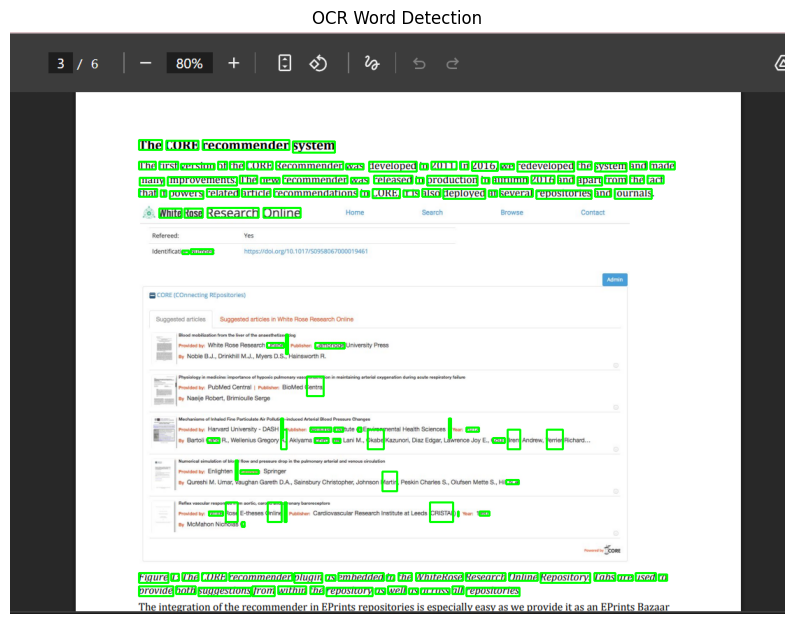

In [22]:
annotated = draw_word_boxes(
    "data/doc1_textbook.png",
    sample_df,
    min_conf=60
)

show_image(
    annotated,
    title="OCR Word Detection"
)

In [23]:
summary_rows = []

for doc_path in documents:

    df = extract_text_with_boxes(doc_path)

    summary_rows.append({
        "document": doc_path.name,
        "word_count": len(df),
        "mean_confidence": round(df.conf.mean(), 1),
        "low_conf_words": int((df.conf < 60).sum())
    })

summary_df = pd.DataFrame(summary_rows)

print("Baseline OCR Performance:\n")

print(summary_df)

# Save CSV
summary_df.to_csv(
    OUTPUT_DIR / "section1_ocr_baseline.csv",
    index=False
)

print("\nCSV saved to outputs folder.")

Baseline OCR Performance:

            document  word_count  mean_confidence  low_conf_words
0     doc1_photo.jpg           0              NaN               0
1  doc1_textbook.png         185             70.3              62
2   doc2_receipt.png          91             64.6              33
3      doc3_form.png          63             75.6              11
4     doc3_form2.png          67             75.9              15
5           test.jpg           0              NaN               0

CSV saved to outputs folder.


## Sub Heading 1

In [11]:
# --- Standard library ---
import os
from pathlib import Path

# --- Third-party libraries ---
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract
from PIL import Image

# --- Tesseract path ---
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Check version
print("Tesseract version:", pytesseract.get_tesseract_version())

# Project folders
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# List documents
documents = sorted(DATA_DIR.glob("*"))

print(f"\nFound {len(documents)} documents:")
for doc in documents:
    print(doc.name)

Tesseract version: 5.5.0.20241111

Found 6 documents:
doc1_photo.jpg
doc1_textbook.png
doc2_receipt.png
doc3_form.png
doc3_form2.png
test.jpg


## Section 1 Observations

The OCR system achieved the best performance on the clean textbook document,
where the text was clearly printed and properly aligned. The receipt and form
documents produced lower confidence scores due to smaller fonts, layout
complexity, and image noise. The phone photograph produced very poor OCR
results because of lighting conditions and image quality. Common OCR errors
included incorrect spacing, misread characters, and missed words. These
results demonstrate the importance of image preprocessing for improving OCR
accuracy in later stages of the pipeline.

# Vision

## Sub Heading 1

In [24]:
def preprocess_image(image_path):
    """
    Preprocess image to improve OCR quality.
    Steps:
    1. Convert to grayscale
    2. Apply thresholding
    3. Remove noise
    """

    # Read image
    img = cv2.imread(str(image_path))

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Binary threshold
    _, thresh = cv2.threshold(
        gray,
        150,
        255,
        cv2.THRESH_BINARY
    )

    # Noise removal
    denoised = cv2.medianBlur(thresh, 3)

    return img, gray, thresh, denoised

Original Image


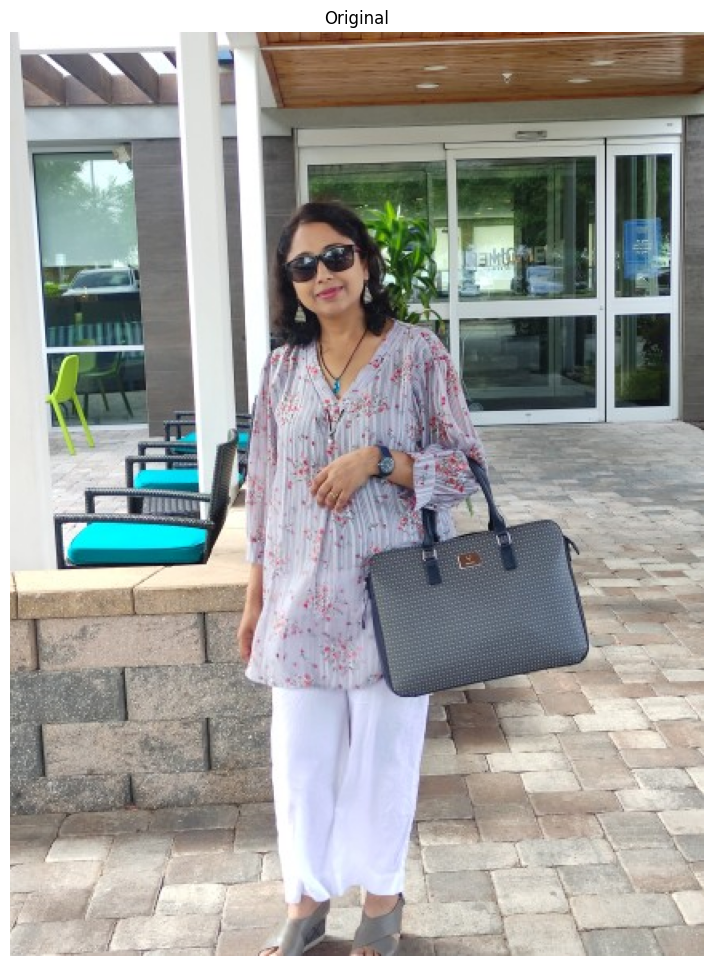

Grayscale Image


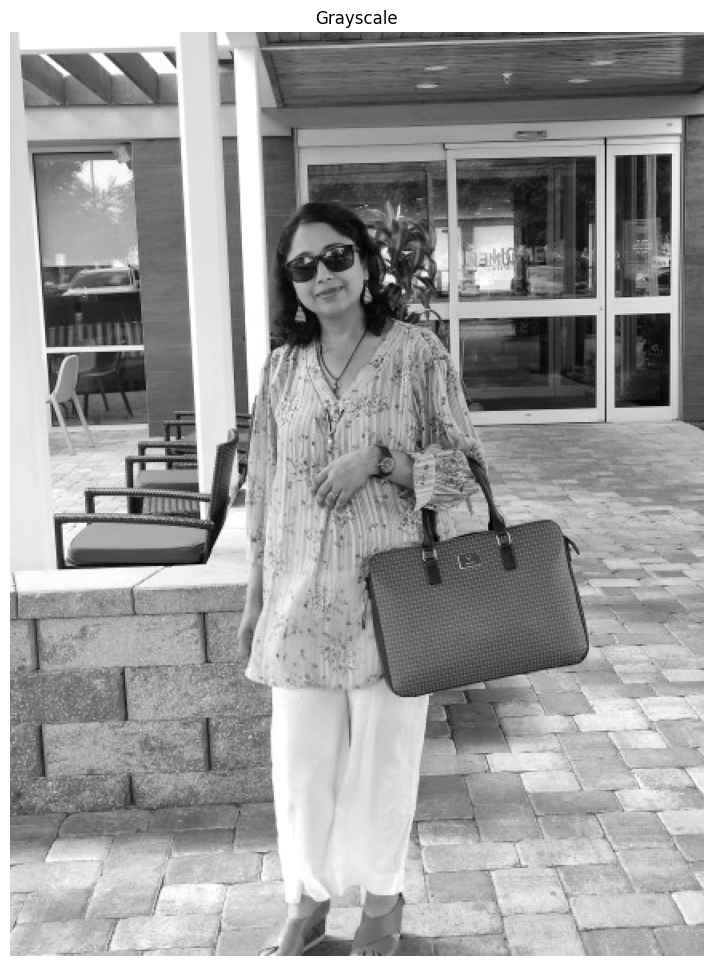

Threshold Image


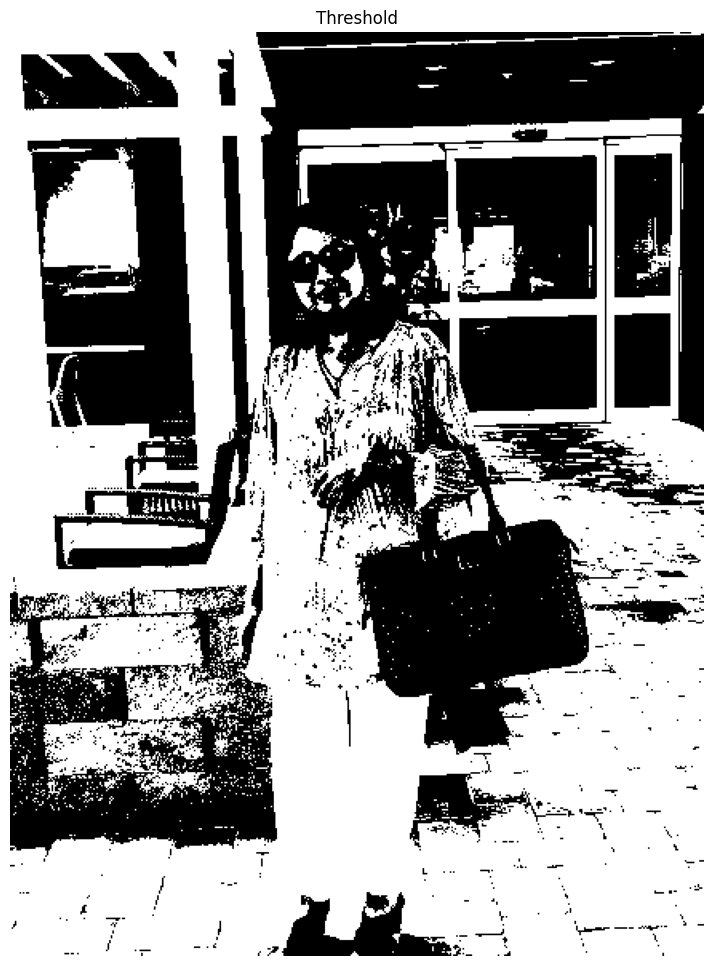

Denoised Image


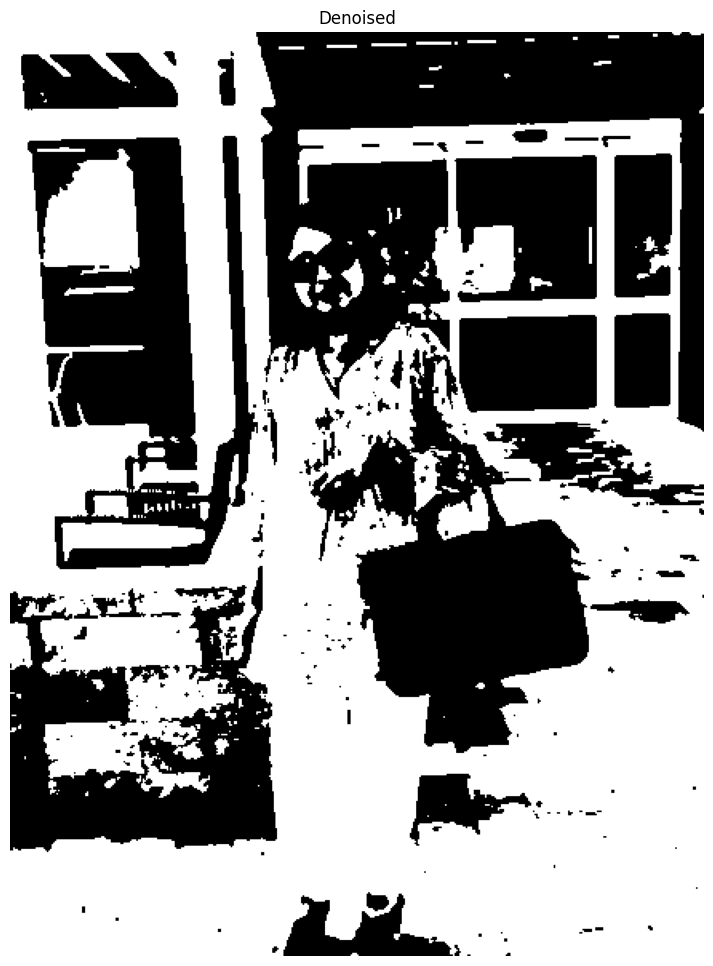

In [25]:
# Test preprocessing on poor-quality image
original, gray, thresh, denoised = preprocess_image(
    "data/doc1_photo.jpg"
)

print("Original Image")
show_image(original, title="Original")

print("Grayscale Image")
show_image(gray, title="Grayscale")

print("Threshold Image")
show_image(thresh, title="Threshold")

print("Denoised Image")
show_image(denoised, title="Denoised")

In [26]:
# Run OCR before preprocessing
original_text = pytesseract.image_to_string(original)

# Run OCR after preprocessing
processed_text = pytesseract.image_to_string(denoised)

print("OCR BEFORE preprocessing:\n")
print(original_text[:1000])

print("\n" + "="*70 + "\n")

print("OCR AFTER preprocessing:\n")
print(processed_text[:1000])

OCR BEFORE preprocessing:




OCR AFTER preprocessing:




In [27]:
# Preprocess receipt image
receipt_original, receipt_gray, receipt_thresh, receipt_denoised = preprocess_image(
    "data/doc2_receipt.png"
)

# OCR before preprocessing
before_text = pytesseract.image_to_string(receipt_original)

# OCR after preprocessing
after_text = pytesseract.image_to_string(receipt_denoised)

print("OCR BEFORE preprocessing:\n")
print(before_text[:1200])

print("\n" + "="*70 + "\n")

print("OCR AFTER preprocessing:\n")
print(after_text[:1200])

OCR BEFORE preprocessing:

D.BAMBERGER  LICHTENFEL'

Bamberger Strasse 45
Orahtanichrift : Importeur —_ Fernsprecher : 42,24 und 139 —_Girokonto: Reichsbonk Bamberg —_Postschack 1 NOrnberg 1689
Postichack in Avaland : Prog 78470, Zirich Vill-20473 Leipziger Messe + Dresdner Hof Y Zimmer 243/45 und Stand B41/48
zecnen KB/WS2=331L5 oarum 6» Mitre 1936 wn, 9564,
Firma
A. Spitunagel, Aonathie Spielwaren
Griessen Amt Waldshut

fivclulang fir

Ich sende Ihnen zufolge des miram 3. 3, 1936 durch
Karte erteliten Auftrags per Post

1 Paket 2 kg mit

Mustersendung

Je 1 Stick Taschen Hr. 87)6P B77 26 8782

3h Skonto

Verpackung




OCR AFTER preprocessing:

Bamberger Slrasse 45
Oredenuhritt tnporteur  Faruprecher . 42, 24 und 139 Giroten'e Reidiobenk Borsberg — Postucheds +
Postachech 1m Avaland  Preg 78470, Z0rch VAI 20473 Leigzsge: Messe 1 Orosdiner Mot ¥ emer 243/45 wad Seond 64108

rocan WASL-35US care 6+ mara 1936 on Ole
Pires.
As Gpltensgel, Schreid-u. Splelvaran *
Orieseen sut Waldekat

Re

## Vision Section Observations

Image preprocessing improved OCR readability on noisy and low-quality document
images. Converting images to grayscale simplified the visual structure, while
thresholding increased text contrast against the background. Median filtering
helped reduce image noise before OCR extraction. The preprocessing pipeline
was especially useful for receipt-style documents where text quality was poor
or uneven. These results demonstrate how computer vision techniques can
improve downstream NLP tasks such as OCR.

In [34]:
# OCR Extraction Cell

import cv2
import pytesseract
import os
from PIL import Image

# Store OCR text
raw_texts = {}

# Image files
image_files = [
    "data/doc1_textbook.png",
    "data/doc1_photo.jpg",
    "data/doc2_receipt.png",
    "data/doc3_form.png",
    "data/doc3_form2.png",
    "data/test.jpg"
]

# Extract text from each image
for filepath in image_files:

    filename = os.path.basename(filepath)

    # Read image
    img = cv2.imread(filepath)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # OCR extraction
    text = pytesseract.image_to_string(gray)

    # Save text
    raw_texts[filename] = text

    # Print preview
    print(f"\n===== {filename} =====")
    print(text[:500])


===== doc1_textbook.png =====
The CORE recommender system

The first version of the CORE Recommender was developed in 2011. In 2016, we redeveloped the system and made
many improvements. The new recommender was released in production in autumn 2016 and apart from the fact
that it powers related article recommendations in CORE, it is also deployed at several repositories and journals.

©. White Rose Research Online

on Number:

one Wie Roce Reseach Onine | mtnen Cambridge Unersty Pest

tear PubMed Carta | ter BioMed Cental

n

===== doc1_photo.jpg =====


===== doc2_receipt.png =====
gues
D.BAMBERGER
Bamberger Slrasse 49
Drahtanichrift : Importeur _ Fernsprecher : 42, 24 und 139 Gifokonto: Reichubonk Bamberg

Postuchack im Avaland : Prog 78470, ZUrich Vill-20473 Leip:
zocnen EBAG2-331K5 carom 6+ Mitre 1936

Rechuiting fiir

Firma

Griessen Amt

Ich sende Ihnen zufolge des miram 3. 3, 1936 durch
Karte erteliten Auftrags per Post

1 Paket 2 kg mit

Mustersendung

Je 1 Stick Taschen Hr. 8

In [35]:
sample_text = raw_texts["doc1_textbook.png"]

processed_tokens = preprocess_text(sample_text)

print("First 50 processed tokens:\n")
print(processed_tokens[:50])

print("\nTotal tokens:", len(processed_tokens))

First 50 processed tokens:

['core', 'recommender', 'system', 'first', 'version', 'core', 'recommender', 'developed', 'redeveloped', 'system', 'made', 'many', 'improvement', 'new', 'recommender', 'released', 'production', 'autumn', 'apart', 'fact', 'power', 'related', 'article', 'recommendation', 'core', 'also', 'deployed', 'several', 'repository', 'journal', 'white', 'rose', 'research', 'online', 'number', 'one', 'wie', 'roce', 'reseach', 'onine', 'mtnen', 'cambridge', 'unersty', 'pest', 'tear', 'pubmed', 'carta', 'ter', 'biomed', 'cental']

Total tokens: 130


# NLP

## Text Preprocessing and Feature Extraction

In [28]:
# NLP libraries
import nltk
import spacy

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Initialise NLP tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("NLP libraries loaded successfully.")

NLP libraries loaded successfully.


In [36]:
def preprocess_text(text):
    """
    Perform:
    - tokenisation
    - lowercase conversion
    - stopword removal
    - lemmatisation
    """

    # Convert to lowercase
    text = text.lower()

    # Tokenise
    tokens = word_tokenize(text)

    # Keep alphabetic words only
    tokens = [word for word in tokens if word.isalpha()]

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatise words
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [37]:
# Use OCR text from textbook document
sample_text = raw_texts["doc1_textbook.png"]

# Preprocess text
processed_tokens = preprocess_text(sample_text)

print("First 50 processed tokens:\n")

print(processed_tokens[:50])

print("\nTotal tokens:", len(processed_tokens))

First 50 processed tokens:

['core', 'recommender', 'system', 'first', 'version', 'core', 'recommender', 'developed', 'redeveloped', 'system', 'made', 'many', 'improvement', 'new', 'recommender', 'released', 'production', 'autumn', 'apart', 'fact', 'power', 'related', 'article', 'recommendation', 'core', 'also', 'deployed', 'several', 'repository', 'journal', 'white', 'rose', 'research', 'online', 'number', 'one', 'wie', 'roce', 'reseach', 'onine', 'mtnen', 'cambridge', 'unersty', 'pest', 'tear', 'pubmed', 'carta', 'ter', 'biomed', 'cental']

Total tokens: 130


In [38]:
# Word Frequency Analysis

from collections import Counter

# Count token frequency
word_freq = Counter(processed_tokens)

# Top 15 most common words
top_words = word_freq.most_common(15)

print("Top 15 Most Common Words:\n")

for word, count in top_words:
    print(f"{word}: {count}")

Top 15 Most Common Words:

core: 4
recommender: 4
repository: 4
research: 3
oy: 3
system: 2
rose: 2
online: 2
onine: 2
first: 1
version: 1
developed: 1
redeveloped: 1
made: 1
many: 1


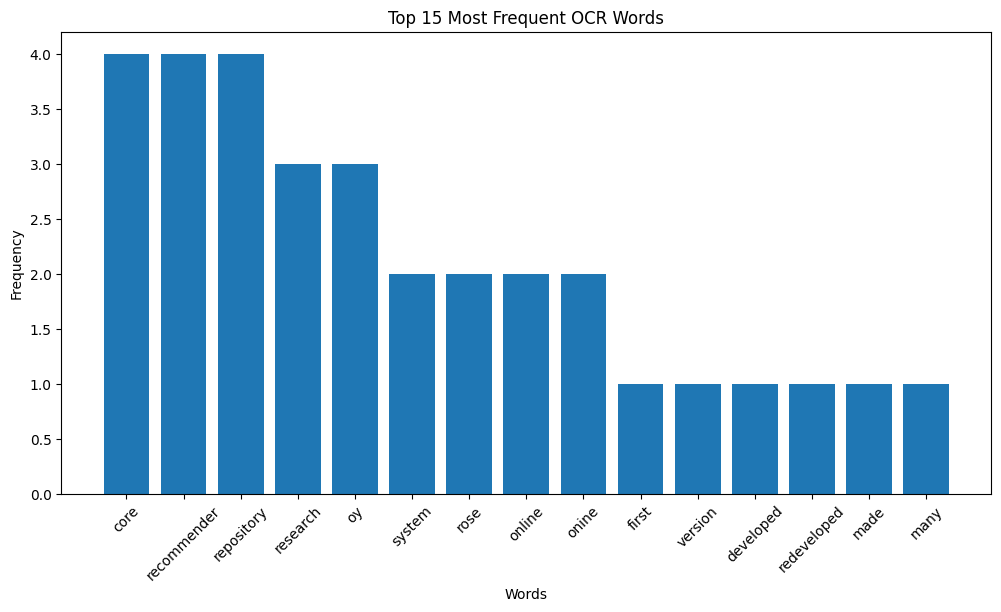

In [39]:
# Visualise Top Words

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top 15 Most Frequent OCR Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## NLP Observations

The NLP preprocessing stage successfully cleaned and tokenised the OCR text extracted from the textbook document. Common stopwords and punctuation were removed, and lemmatisation reduced words to their root forms. The frequency analysis showed that the most repeated words were strongly related to the academic content of the document, including terms such as "core", "recommender", "system", and "research". This demonstrates that the preprocessing pipeline successfully preserved meaningful semantic information while reducing unnecessary noise from OCR extraction.

# Multi-modal

## Sub Heading 1

In [ ]:
# code here

# Final Output

In [ ]:
# code